# Applying the Jacobian correction to spectral data

When we measure spectra with the spectrometer, we get counts against wavelength. Often, we want to work in energy because it tells us information about the electronic transitions available in the material we are investigating. We might be tempted to simply convert our wavelength axis to energy with the following formula

$$
E=\frac{hc}{\lambda}
$$

but doing so neglects the fact that we are not measuring counts at single wavelength data points. In practice, our spectrometer has a grating which separates the incoming light via diffraction. The diffracted signal hits a CCD and the counts over each pixel is integrated to give us a counts over some interval $\mathrm{d}\lambda$ which is related to the grating density.

Since energy and wavelength are inversely related, using the formula above to transform the wavelength axis to energy while using an uncorrected counts signal means that the counts per axis interval is distorted. To correct for this distortion, we need to apply the Jacobian. This is motivated by the fact that the total number of photons recorded must be the same in wavelength and energy units. Mathematically,

$$
\intop_{-\infty}^{\infty} I(\lambda)\;\mathrm{d}\lambda = \intop_{-\infty}^{\infty}I(E)\;\mathrm{d}E
$$

When we perform a change of variables, we apply the Jacobian,

$$
I_E(E) = I_\lambda(\lambda) \frac{\mathrm{d}\lambda}{\mathrm{d}E} = I_\lambda(\lambda) \frac{\lambda^2}{hc}
$$

This notebook shows:
1. How converting the wavelength axis to energy without the Jacobian distorts the peak shape, position, and asymmetry.
2. That only the corrected spectrum conserves the integrated intensity.
3. How the distortion depends on the spectral bandwidth.
4. Applying the Jacobian correction requires a zero baseline

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from leman.processing import jacobian_correction_wvl2E, wavelength_to_energy
from leman.fitting import lorentzian
from leman.constants import HC_EV_NM
from pathlib import Path

## Part 1: A broad emission band

The Jacobian factor is $\lambda^2 / hc$. This varies slowly across a narrow peak but significantly across a broad one. To see the distortion clearly, we use a peak with a large fractional bandwidth $\Delta\lambda / \lambda$ — for example, a broad defect emission band centred at 1000 nm with a 200 nm FWHM.

In [83]:
wavelength = np.linspace(500, 1500, 3000)  # nm

# Broad emission band: 200 nm FWHM centred at 1000 nm.
signal = lorentzian(wavelength, amplitude=1000, center=1000, fwhm=300)

def noisy_lorentzian(wavelength, amplitude, center, fwhm, offset, noise_sigma):
    return lorentzian(wavelength, amplitude, center, fwhm) + np.random.normal(0, noise_sigma, len(wavelength)) + offset

signal = noisy_lorentzian(wavelength, amplitude=1000, center=1000, fwhm=300, offset=0, noise_sigma=10)

Convert the wavelength axis to energy. The **uncorrected** curve simply replots the same counts against the new axis. The **corrected** curve applies the Jacobian using `jacobian_correction_wvl2E`, which multiplies by $\lambda^2 / hc$ in consistent units (nm and eV).

In [84]:
energy = HC_EV_NM/wavelength  # eV

# Uncorrected: same counts, just replotted against energy.
signal_uncorrected = signal

# Corrected: counts × λ²/(hc) in nm/eV units.
signal_corrected = signal * (wavelength**2)/(HC_EV_NM)

### Comparing the two on the energy axis

The uncorrected curve has units of counts (the raw measurement). The corrected curve has units of counts $\times$ nm/eV (spectral density per unit energy). These are different physical quantities, so comparing their amplitudes is meaningless — we normalise both to their peak to compare the *shape*.

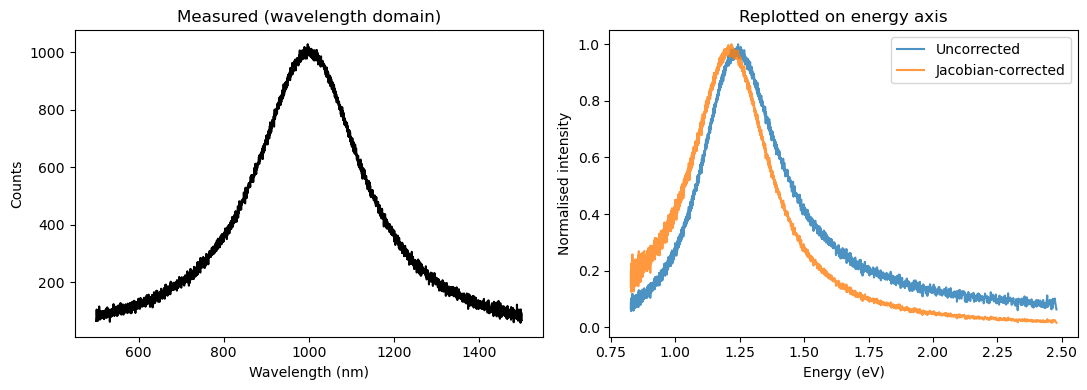

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: wavelength domain (the measurement).
axes[0].plot(wavelength, signal, color="black")
axes[0].set_xlabel("Wavelength (nm)")
axes[0].set_ylabel("Counts")
axes[0].set_title("Measured (wavelength domain)")

# Right: energy domain — normalised to compare shape.
axes[1].plot(energy, signal_uncorrected / signal_uncorrected.max(),
             label="Uncorrected", alpha=0.8)
axes[1].plot(energy, signal_corrected / signal_corrected.max(),
             label="Jacobian-corrected", alpha=0.8)
axes[1].set_xlabel("Energy (eV)")
axes[1].set_ylabel("Normalised intensity")
axes[1].set_title("Replotted on energy axis")
axes[1].legend()

fig.tight_layout()

The two curves differ in two ways:
- Peak position: the corrected peak is red-shifted (lower energy). The Jacobian factor $\lambda^2/hc$ grows with wavelength, so it weights the long-wavelength (low-energy) side of the peak more heavily, pulling the apparent centre.
- Asymmetry: the original Lorentzian is symmetric in wavelength. Without the correction it stays symmetric when replotted against energy — but a symmetric peak in wavelength is *not* symmetric in energy. The Jacobian restores the correct asymmetry. At low wavelengths, a given $\mathrm{d}\lambda$ spans a large $\mathrm{dE}$, which stretches the higher energy side of the Lorentzian while the low energy side gets compressed.

### Integrated intensity must be conserved

The defining property of the Jacobian correction is that the integrated spectral density is the same in both domains. We can verify this numerically with `np.trapezoid`.

In [76]:
area_wavelength = np.trapezoid(signal, wavelength)

# Energy runs high-to-low when wavelength runs low-to-high, so we
# flip both arrays to integrate in the positive direction.
area_uncorrected = np.trapezoid(signal_uncorrected[::-1], energy[::-1])
area_corrected   = np.trapezoid(signal_corrected[::-1], energy[::-1])

print(f"Integrated intensity in wavelength domain: {area_wavelength:.1f}")
print(f"Integrated intensity in energy (uncorrected): {area_uncorrected:.1f}")
print(f"Integrated intensity in energy (corrected):   {area_corrected:.1f}")
print(f"\nRatio corrected/wavelength: {area_corrected / area_wavelength:.6f}")
print(f"Ratio uncorrected/wavelength: {area_uncorrected / area_wavelength:.6f}")

Integrated intensity in wavelength domain: 383892.0
Integrated intensity in energy (uncorrected): 540.0
Integrated intensity in energy (corrected):   383892.0

Ratio corrected/wavelength: 1.000000
Ratio uncorrected/wavelength: 0.001407


The corrected integral matches the wavelength-domain integral (ratio ≈ 1). The uncorrected integral does not.

## Part 2: How distortion depends on bandwidth

The Jacobian effect is controlled by the fractional bandwidth $\Delta\lambda / \lambda$. A narrow excitonic peak at 700 nm has a small fractional bandwidth and the correction barely changes the shape. A broad defect band or room-temperature PL has a large fractional bandwidth and the distortion is significant.

To show this, we compare three peaks at the same centre wavelength (1000 nm) with increasing FWHM.

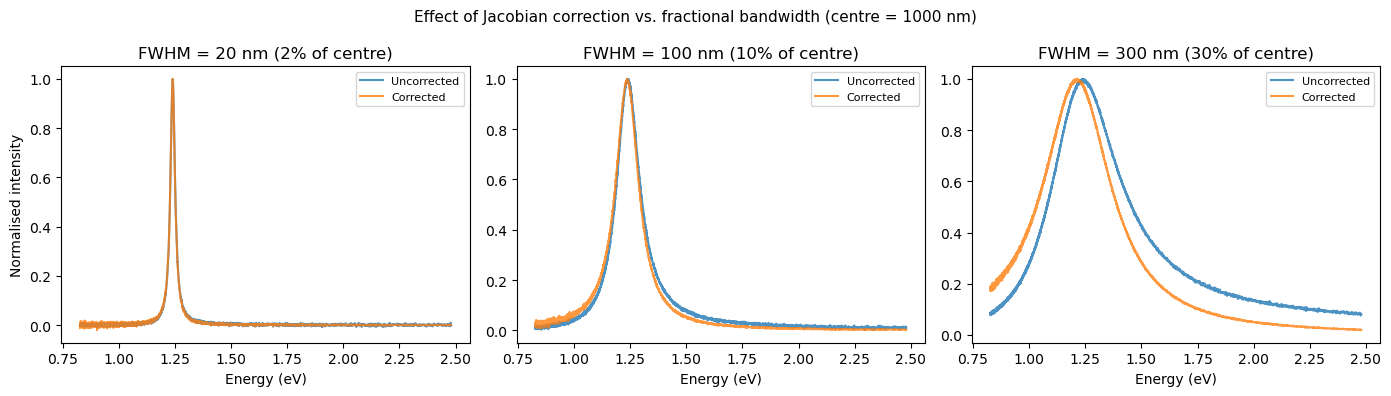

In [77]:
fwhms = [20, 100, 300]  # nm
center = 1000  # nm

fig, axes = plt.subplots(1, len(fwhms), figsize=(14, 4), sharey=False)

for ax, fwhm in zip(axes, fwhms):
    sig = noisy_lorentzian(wavelength, amplitude=1000, center=center, fwhm=fwhm, offset=0, noise_sigma=3)
    sig_corr = sig * (wavelength**2)/(HC_EV_NM)

    # Normalise to peak so we can compare shapes side by side.
    ax.plot(energy, sig / sig.max(), label="Uncorrected", alpha=0.8)
    ax.plot(energy, sig_corr / sig_corr.max(), label="Corrected", alpha=0.8)
    ax.set_xlabel("Energy (eV)")
    ax.set_title(f"FWHM = {fwhm} nm ({fwhm/center*100:.0f}% of centre)")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Normalised intensity")
fig.suptitle(f"Effect of Jacobian correction vs. fractional bandwidth (centre = {center} nm)",
             fontsize=11)
fig.tight_layout()

At 20 nm FWHM (2% fractional bandwidth), the two curves are nearly identical — the correction barely matters. At 300 nm FWHM (30%), the uncorrected curve has a visibly different peak position and shape. Normalising is appropriate here because we are comparing *shape*, not amplitude.

## Part 4: Applying the Jacobian correction requires a zero baseline

Thus far, we have been working with signals with zero dark counts (a zero baseline). In practice, real signals do not have a zero baseline. There could be noise, dark counts, etc. Applying the Jacobian in such a case results in the following

In [78]:
signal = noisy_lorentzian(wavelength, amplitude=1000, center=1000, fwhm=300, offset=200, noise_sigma=10)
signal_uncorrected = signal
signal_corrected = signal * (wavelength**2)/(HC_EV_NM)

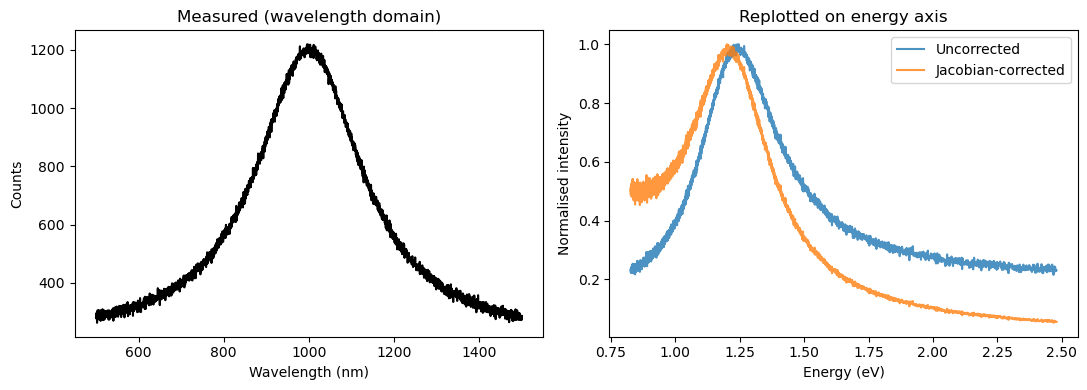

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: wavelength domain (the measurement).
axes[0].plot(wavelength, signal, color="black")
axes[0].set_xlabel("Wavelength (nm)")
axes[0].set_ylabel("Counts")
axes[0].set_title("Measured (wavelength domain)")

# Right: energy domain — normalised to compare shape.
axes[1].plot(energy, signal_uncorrected / signal_uncorrected.max(),
             label="Uncorrected", alpha=0.8)
axes[1].plot(energy, signal_corrected / signal_corrected.max(),
             label="Jacobian-corrected", alpha=0.8)
axes[1].set_xlabel("Energy (eV)")
axes[1].set_ylabel("Normalised intensity")
axes[1].set_title("Replotted on energy axis")
axes[1].legend()

fig.tight_layout()

The most striking thing we observe is that the corrected signal displays a tilt: the low energy portion of the signal is tilted upwards. This is because for a constant offset, applying the Jacobian scales the signal by $\lambda^2/hc$ which means that this constant offset is scaled more at shorter wavelengths. We can correct for this by identifying the offset and subtracting it from the signal before applying the Jacobian correction

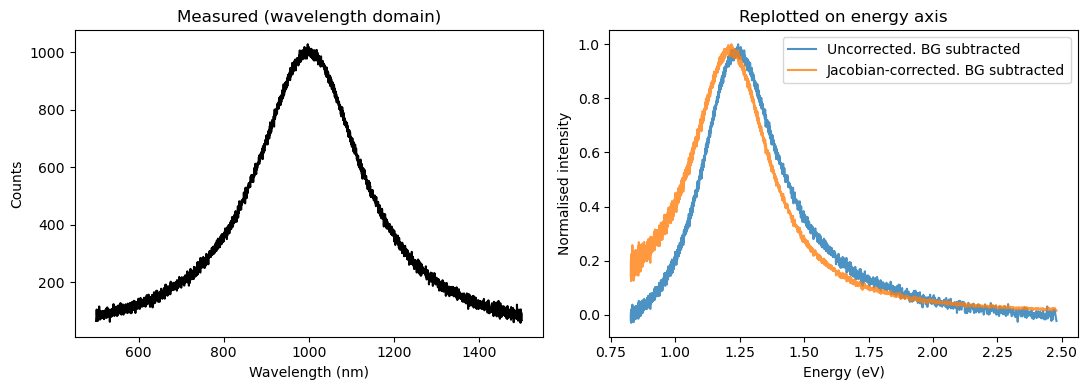

In [86]:
signal_offset = np.mean(signal[:10])
signal_uncorrected = signal - signal_offset
signal_corrected = signal * (wavelength**2)/(HC_EV_NM) - signal_offset

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: wavelength domain (the measurement).
axes[0].plot(wavelength, signal, color="black")
axes[0].set_xlabel("Wavelength (nm)")
axes[0].set_ylabel("Counts")
axes[0].set_title("Measured (wavelength domain)")

# Right: energy domain — normalised to compare shape.
axes[1].plot(energy, signal_uncorrected / signal_uncorrected.max(),
             label="Uncorrected. BG subtracted", alpha=0.8)
axes[1].plot(energy, signal_corrected / signal_corrected.max(),
             label="Jacobian-corrected. BG subtracted", alpha=0.8)
axes[1].set_xlabel("Energy (eV)")
axes[1].set_ylabel("Normalised intensity")
axes[1].set_title("Replotted on energy axis")
axes[1].legend()

fig.tight_layout()